# Survey-Selektor-Vergleich — interval1 (kompletter Flug, mono + GPS)

Survey-level Vergleich **aller Frame-Selektoren** auf dem vollen
interval1_AMtown03-Cruise-Survey (8000 Frames, je 16 ueberlappende 500-Frame-Segmente,
Step 300). Pro Selektor wird sein **s1000-Sweep-Gewinner** gefahren, alle Segmente per
`sim3_unwarp --gps-csv` driftfrei zusammengesetzt und zu einer `survey_complete.ply`
gemergt. Quelle: `docs/results/survey_selectors_summary.csv` (**1 Zeile pro Selektor**,
geschrieben von `scripts/eval/measure_survey.py`).

Das ist eine Granularitaet ueber den `analyze_sweep_*`-Notebooks: dort 1 Zeile/Variant
auf einem 200/400-Frame-Slice, hier 1 Zeile/Selektor ueber den **kompletten Flug**.

### ⚠️ Lesehinweis — zwei Confounds, immer mitdenken
1. **Coverage-Confound.** `n_ok` = wie viele der 16 Segmente den VRAM-Wall ueberlebt
   haben (`rc=137`-Kill bei ~8 GiB, siehe `feedback_vram_watchdog`). `psnr_*`, `ssim_*`,
   `lpips_*`, `ate_*` sind **nur ueber die OK-Segmente** gemittelt. Ein Selektor mit
   `n_ok=6` wurde nur auf den (oft einfacheren) ueberlebenden Regionen bewertet → seine
   Qualitaetszahlen sind **nicht fair** gegen einen mit `n_ok=16` vergleichbar. Plots
   markieren `n_ok<10` mit Schraffur und zeigen `(n_ok/16)` an den Achsen.
2. **Non-metrische Posen.** Der Survey laeuft non-metrisch (`--no-ext`, DROID-Frame); GPS
   verankert erst im Post-Process. `ate_rmse_m` misst Tracker-Drift, **nicht** die
   Kartengenauigkeit; `psnr_ho` ist held-out, aber auf DROID-Posen interpoliert. Werte
   sind als *relativer* Selektor-Vergleich zu lesen, nicht als Absolutgenauigkeit.

### 🔧 Update 2026-06-10 — `two_gate_v2_tuned`
Der urspruengliche `two_gate_v2` war Survey-Letzter (psnr_ho 8.64), weil seine auf dem
**metrischen** s1000-Slice getunten Schwellen den Mapper auf dem **non-metrischen** Survey
aushungerten (nur 201 gemappte Frames). Die getunte Variante `two_gate_v2_tuned`
(`pose_d_min_m 0.2→0.1`, Rate-Cap `max_per_window 2→6`, `theta0 0.15→0.08`,
`gate_a.gps_d_min_m 0.4→0.2`) mappt 479 Frames und hebt psnr_ho auf **10.34** (+1.7 dB) bei
gleicher ATE und 16/16 Segmenten. Beide Zeilen sind hier nebeneinander sichtbar
(Vorher/Nachher). Siehe `project_two_gate_survey_tuning`.

### Inhalt
1. Overview-Tabelle
2. Segment-Robustheit — wie viele Segmente ueberleben den VRAM-Wall
3. Mapping-Last pro Selektor (Mapper-KFs / Gaussians / PLY-MB / Peak-VRAM)
4. Qualitaet pro Selektor (held-out PSNR, ATE) — mit Coverage-Schraffur
5. Kernfrage: PSNR ↔ Laufzeit (Pareto-Front)
6. These: weniger Mapping-Last → mehr Segmente ueberleben
7. Tracking ↔ Mapping (quality–quality)
8. Karten-Kompaktheit + Laufzeit
9. PSNR-Streuung ueber Segmente

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# self-contained CSV-Resolver (wie in den analyze_sweep_*-Notebooks)
def _find_csv(name):
    cands = [Path(name), Path('docs/results')/name,
             Path.home()/'Dokumente/Github/VINGS-Mono-BA/docs/results'/name]
    for c in cands:
        if c.exists():
            return c
    return cands[-1]

CSV = _find_csv('survey_selectors_summary.csv')
df = (pd.read_csv(CSV)
        .sort_values('timestamp')
        .drop_duplicates('survey_name', keep='last')
        .reset_index(drop=True))

N_SEG = 16
df['coverage']      = df['n_ok'] / df['n_segments']
df['mapped_per_ok'] = df['n_mapped_total'] / df['n_ok']          # Throttle-Intensitaet
df['gauss_M']       = df['n_gaussians_merged'] / 1e6
df['is_baseline']   = df['survey_name'] == 'none'

# feste Selektor-Farben (baseline grau), stabil ueber alle Plots
SELS = df['survey_name'].tolist()
# tab20 statt tab10: der Survey hat jetzt 11 Selektoren (inkl. two_gate_v2_tuned),
# tab10 (10 Farben) wuerde die 11. Zeile aus _pal werfen -> KeyError in C()/_pal[...].
_cmap = plt.cm.tab20.colors
_pal = {s: _cmap[i % len(_cmap)] for i, s in enumerate(SELS)}
_pal['none'] = (0.30, 0.30, 0.30)
def C(order):  return [_pal[s] for s in order]

print(f'CSV: {CSV}')
print(f'{len(df)} Selektoren · interval1 · je {N_SEG} Segmente\n')
show = ['survey_name','n_ok','n_fail','n_mapped_total','gauss_M','ply_mb_merged',
        'psnr_ho_mean','ate_rmse_m_wmean','peak_vram_mib_max','duration_total_min']
print(df.sort_values(['n_ok','psnr_ho_mean'], ascending=False)[show]
        .to_string(index=False, float_format=lambda v: f'{v:.1f}'))

CSV: /home/philipp/Dokumente/Github/VINGS-Mono-BA/docs/results/survey_selectors_summary.csv
11 Selektoren · interval1 · je 16 Segmente

      survey_name  n_ok  n_fail  n_mapped_total  gauss_M  ply_mb_merged  psnr_ho_mean  ate_rmse_m_wmean  peak_vram_mib_max  duration_total_min
two_gate_v2_tuned    16       0           479.0      7.0         1704.9          10.3              13.4             5680.0                29.6
            vista    16       0           572.0      8.0         1956.2           9.4              18.5             6109.0                47.5
           mm3dgs    16       0           451.0      6.9         1693.4           9.0              18.0             4692.0                43.6
      two_gate_v2    16       0           201.0      3.8          934.2           8.6              13.5             1790.0                22.8
      adaptive_kf    16       0            97.0      1.4          348.2           7.1              18.8             4377.0                38.8
      

## 2) Segment-Robustheit — wer ueberlebt den VRAM-Wall?

Jeder Survey besteht aus 16 Segmenten. Ein Segment stirbt `rc=137`, wenn ungezuegeltes
Mapping den ~8-GiB-Peak reisst (gruen = OK, rot = gekillt; Label = Peak-VRAM des Surveys).
**Das ist die zentrale Beobachtung:** Selektoren, die die Mapping-Last drosseln, halten
den VRAM klein und bringen den kompletten Flug durch — `none` (kein Selektor) schafft nur
6/16, weil es jeden Tracker-KF mappt.

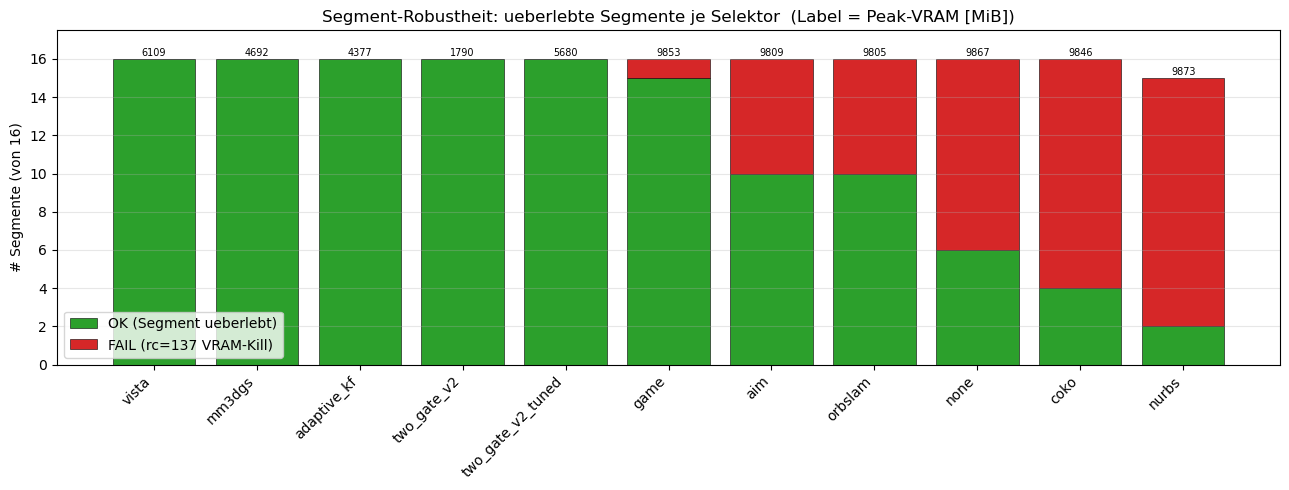

In [8]:
o = df.sort_values('n_ok', ascending=False).reset_index(drop=True)
x = np.arange(len(o))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x, o['n_ok'],  color='#2ca02c', edgecolor='black', lw=.4, label='OK (Segment ueberlebt)')
ax.bar(x, o['n_fail'], bottom=o['n_ok'], color='#d62728', edgecolor='black', lw=.4,
       label='FAIL (rc=137 VRAM-Kill)')
for xi, (_, r) in zip(x, o.iterrows()):
    ax.text(xi, r['n_segments'] + 0.15, f"{int(r['peak_vram_mib_max'])}", ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(o['survey_name'], rotation=45, ha='right')
ax.set_ylabel('# Segmente (von 16)'); ax.set_ylim(0, N_SEG + 1.5)
ax.set_title('Segment-Robustheit: ueberlebte Segmente je Selektor  (Label = Peak-VRAM [MiB])')
ax.legend(loc='lower left'); ax.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

## 3) Mapping-Last pro Selektor

Die vier Kostentreiber des Mappers — **weniger = leichter**. `n_mapped_total` = wie viele
Tracker-KFs der Selektor an den Mapper durchgelassen hat (summiert ueber OK-Segmente),
plus die resultierende Kartengroesse (Gaussians, PLY-MB) und der Peak-VRAM.

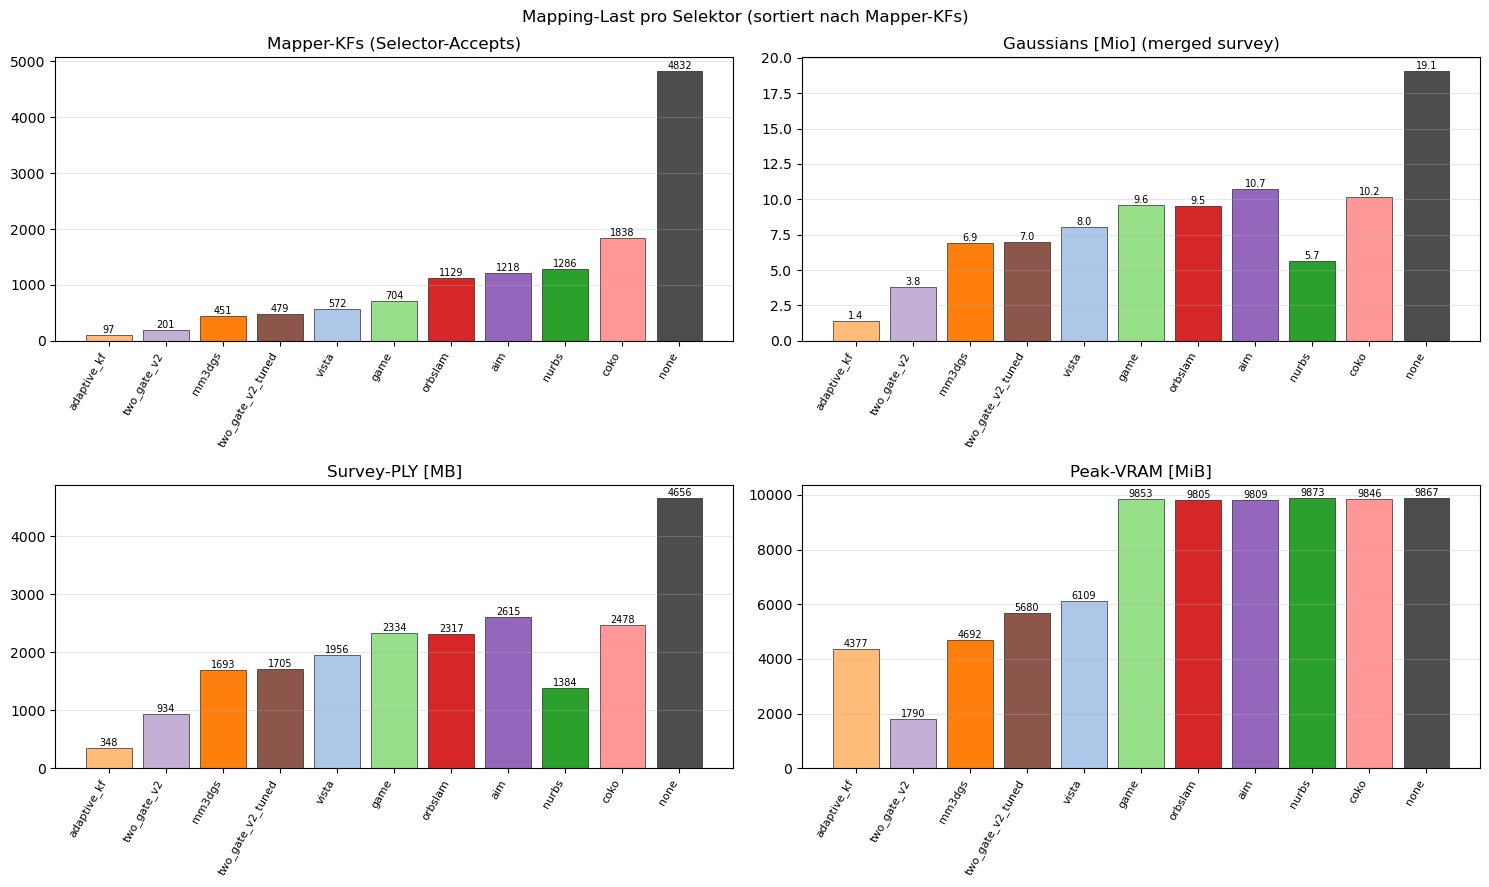

In [9]:
o = df.sort_values('n_mapped_total').reset_index(drop=True)
x = np.arange(len(o)); c = C(o['survey_name'])
panels = [('n_mapped_total', 'Mapper-KFs (Selector-Accepts)'),
          ('gauss_M',        'Gaussians [Mio] (merged survey)'),
          ('ply_mb_merged',  'Survey-PLY [MB]'),
          ('peak_vram_mib_max', 'Peak-VRAM [MiB]')]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for (col, t), ax in zip(panels, axes.ravel()):
    ax.bar(x, o[col], color=c, edgecolor='black', lw=.4)
    ax.set_xticks(x); ax.set_xticklabels(o['survey_name'], rotation=60, ha='right', fontsize=8)
    ax.set_title(t); ax.grid(alpha=.3, axis='y')
    fmt = (lambda v: f'{v:.1f}') if col == 'gauss_M' else (lambda v: f'{v:.0f}')
    for xi, v in zip(x, o[col]):
        ax.text(xi, v, fmt(v), ha='center', va='bottom', fontsize=7)
fig.suptitle('Mapping-Last pro Selektor (sortiert nach Mapper-KFs)', fontsize=12)
fig.tight_layout(); plt.show()

## 4) Qualitaet pro Selektor — held-out PSNR + ATE

**Schraffierte Balken = `n_ok < 10`**: nur ueber wenige (ueberlebende) Segmente gemittelt,
also **nicht fair** vergleichbar (Coverage-Confound, siehe Lesehinweis). Achsenlabel zeigt
`(n_ok/16)`. `psnr_ho` = held-out Novel-View (groesser besser), `ate_rmse_m_wmean` =
frame-gewichteter Trajektorien-Drift (kleiner besser).

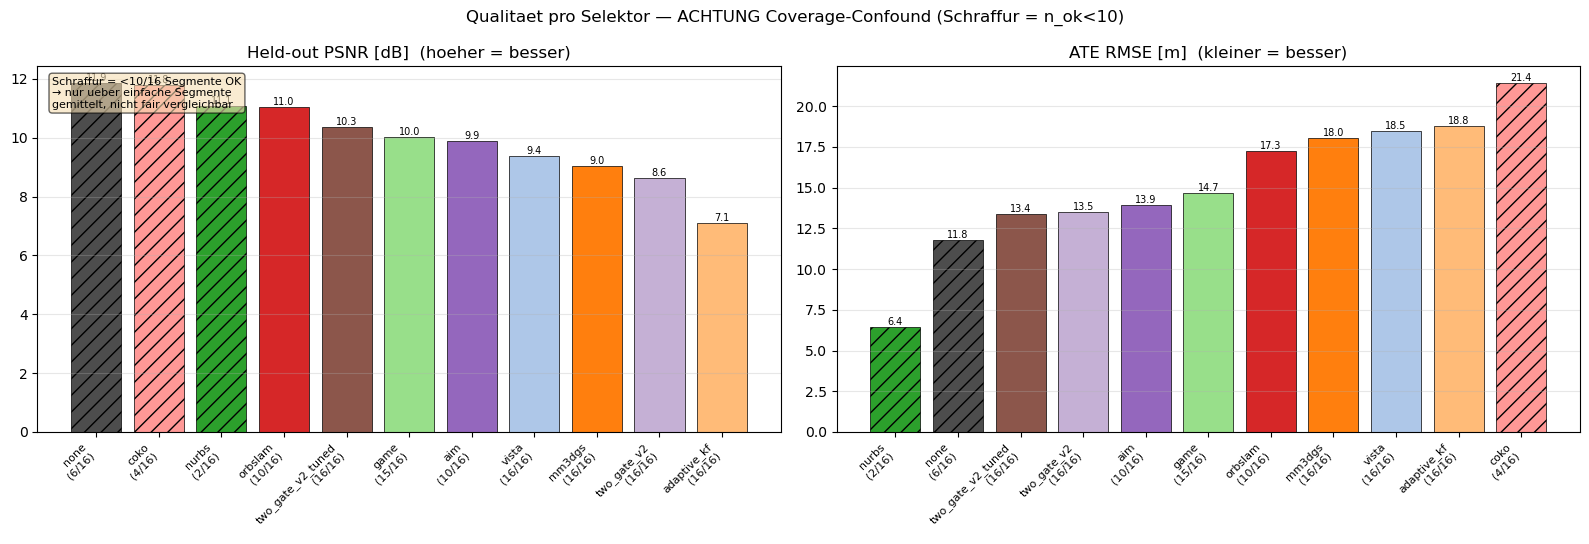

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for col, t, ax, asc in [('psnr_ho_mean',    'Held-out PSNR [dB]  (hoeher = besser)', axes[0], False),
                        ('ate_rmse_m_wmean','ATE RMSE [m]  (kleiner = besser)',      axes[1], True)]:
    oo = df.sort_values(col, ascending=asc).reset_index(drop=True)
    xx = np.arange(len(oo))
    bars = ax.bar(xx, oo[col], color=C(oo['survey_name']), edgecolor='black', lw=.5)
    for b, n in zip(bars, oo['n_ok']):
        if n < 10:
            b.set_hatch('//')
    ax.set_xticks(xx)
    ax.set_xticklabels([f'{s}\n({int(n)}/16)' for s, n in zip(oo['survey_name'], oo['n_ok'])],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(t); ax.grid(alpha=.3, axis='y')
    for xi, v in zip(xx, oo[col]):
        ax.text(xi, v, f'{v:.1f}', ha='center', va='bottom', fontsize=7)
axes[0].text(0.02, 0.97, 'Schraffur = <10/16 Segmente OK\n→ nur ueber einfache Segmente\ngemittelt, nicht fair vergleichbar',
             transform=axes[0].transAxes, va='top', fontsize=8,
             bbox=dict(boxstyle='round', fc='wheat', alpha=.6))
fig.suptitle('Qualitaet pro Selektor — ACHTUNG Coverage-Confound (Schraffur = n_ok<10)', fontsize=12)
fig.tight_layout(); plt.show()

## 5) Kernfrage der Arbeit — PSNR vs Laufzeit (Pareto-Front)

Direkt analog zur Pareto-Zelle der `analyze_sweep_*`-Notebooks. X = Gesamt-Laufzeit des
Surveys (seriell, alle Segmente), Y = held-out PSNR. Die **Pareto-Front** (rot gestrichelt)
verbindet die nicht-dominierten Punkte: kuerzeste Laufzeit bei hoechstem PSNR — **links-oben
= schnell & gut**. Punktgroesse = # OK-Segmente (Coverage-Confound mitlesen: kleine Punkte
sind nur auf Teilstrecken bewertet, ihre Laufzeit ist entsprechend auch kuerzer, weil
Segmente frueh am VRAM-Wall starben).

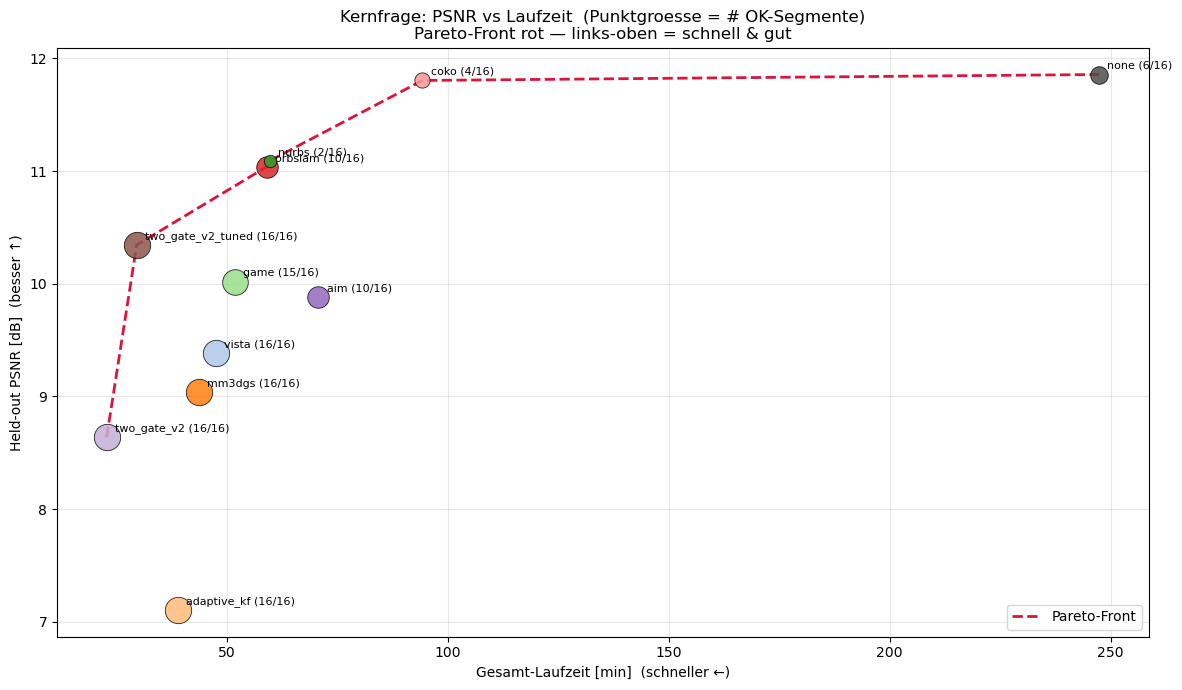

Pareto-Front (kuerzeste Laufzeit -> hoechster PSNR):
      survey_name  duration_total_min  psnr_ho_mean  n_ok  n_mapped_total
      two_gate_v2                22.8           8.6    16           201.0
two_gate_v2_tuned                29.6          10.3    16           479.0
          orbslam                59.0          11.0    10          1129.0
            nurbs                59.7          11.1     2          1286.0
             coko                94.2          11.8     4          1838.0
             none               247.4          11.9     6          4832.0


In [11]:
def pareto_front(d, x='duration_total_min', y='psnr_ho_mean'):
    s = d.sort_values(x).reset_index(drop=True)
    best = -np.inf; mask = []
    for v in s[y]:
        keep = v > best
        mask.append(keep)
        if keep:
            best = v
    s = s.copy(); s['on_front'] = mask
    return s

pf = pareto_front(df)
front = pf[pf['on_front']].sort_values('duration_total_min')

fig, ax = plt.subplots(figsize=(12, 7))
for _, r in pf.iterrows():
    ax.scatter(r['duration_total_min'], r['psnr_ho_mean'],
               s=40 + r['n_ok'] * 20, color=_pal[r['survey_name']],
               edgecolor='black', lw=.6, alpha=.85, zorder=3)
    ax.annotate(f"{r['survey_name']} ({int(r['n_ok'])}/16)",
                (r['duration_total_min'], r['psnr_ho_mean']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.plot(front['duration_total_min'], front['psnr_ho_mean'],
        color='crimson', lw=2, ls='--', zorder=2, label='Pareto-Front')
ax.set_xlabel('Gesamt-Laufzeit [min]  (schneller ←)')
ax.set_ylabel('Held-out PSNR [dB]  (besser ↑)')
ax.set_title('Kernfrage: PSNR vs Laufzeit  (Punktgroesse = # OK-Segmente)\n'
             'Pareto-Front rot — links-oben = schnell & gut')
ax.grid(alpha=.3); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

print('Pareto-Front (kuerzeste Laufzeit -> hoechster PSNR):')
print(front[['survey_name','duration_total_min','psnr_ho_mean','n_ok','n_mapped_total']]
        .to_string(index=False, float_format=lambda v: f'{v:.1f}'))

## 6) These: weniger Mapping-Last → mehr Segmente ueberleben

X = durchschnittlich gemappte KFs **pro OK-Segment** (= Throttle-Intensitaet, unabhaengig
davon wie viele Segmente ueberlebt haben), Y = # OK-Segmente. Der Trend nach oben-links
ist der Kern-Hebel der Arbeit: wer pro Segment weniger mappt, haelt den VRAM klein und
bringt den ganzen Flug durch.

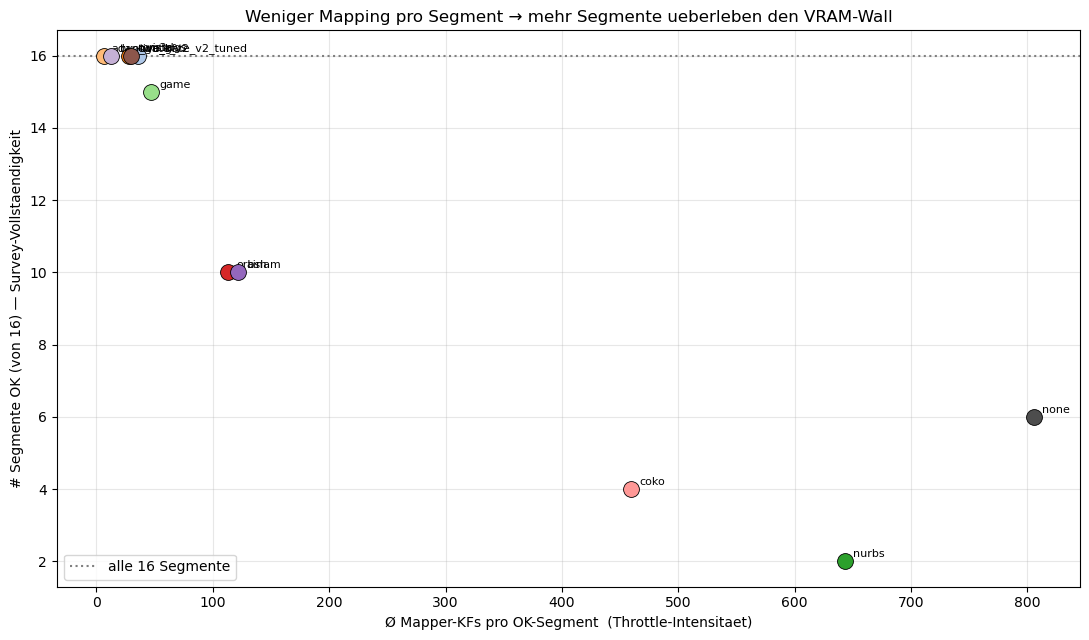

In [12]:
fig, ax = plt.subplots(figsize=(11, 6.5))
for _, r in df.iterrows():
    ax.scatter(r['mapped_per_ok'], r['n_ok'], s=130, color=_pal[r['survey_name']],
               edgecolor='black', lw=.6, zorder=3)
    ax.annotate(r['survey_name'], (r['mapped_per_ok'], r['n_ok']),
                xytext=(6, 3), textcoords='offset points', fontsize=8)
ax.axhline(N_SEG, ls=':', color='grey', label='alle 16 Segmente')
ax.set_xlabel('Ø Mapper-KFs pro OK-Segment  (Throttle-Intensitaet)')
ax.set_ylabel('# Segmente OK (von 16) — Survey-Vollstaendigkeit')
ax.set_title('Weniger Mapping pro Segment → mehr Segmente ueberleben den VRAM-Wall')
ax.legend(loc='lower left'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7) Tracking ↔ Mapping — beide Achsen, rechts-oben = gut

X = ATE (invertiert, **rechts = besser**), Y = held-out PSNR. Markergroesse = # OK-Segmente.
Wieder Coverage-Confound: kleine Marker (z.B. `nurbs` mit 2/16) sind nicht fair gegen die
16/16-Selektoren zu lesen.

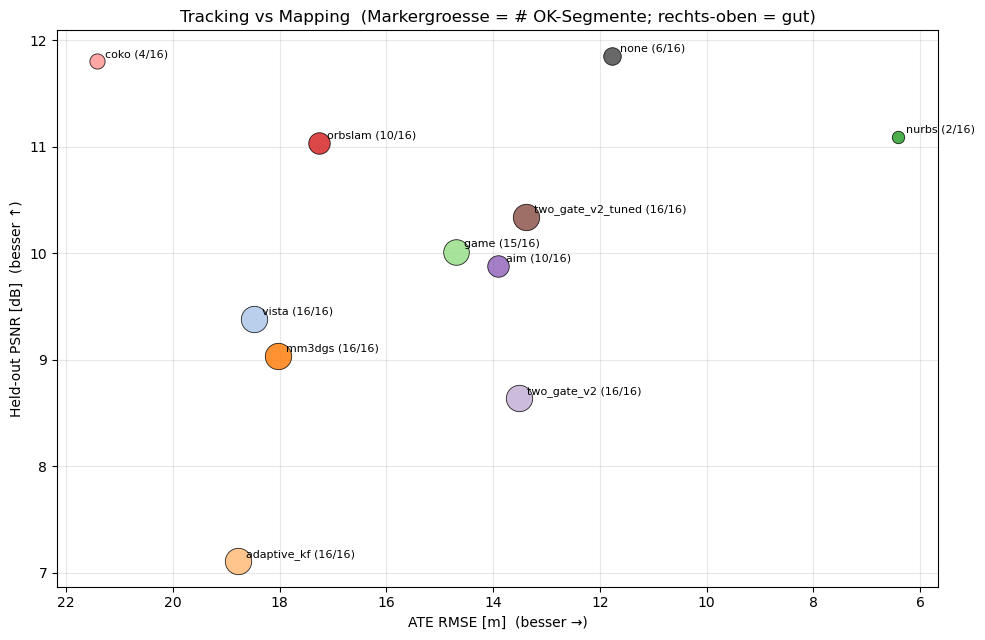

In [13]:
fig, ax = plt.subplots(figsize=(10, 6.5))
for _, r in df.iterrows():
    ax.scatter(r['ate_rmse_m_wmean'], r['psnr_ho_mean'],
               s=40 + r['n_ok'] * 20, color=_pal[r['survey_name']],
               edgecolor='black', lw=.6, alpha=.85, zorder=3)
    ax.annotate(f"{r['survey_name']} ({int(r['n_ok'])}/16)",
                (r['ate_rmse_m_wmean'], r['psnr_ho_mean']),
                xytext=(6, 3), textcoords='offset points', fontsize=8)
ax.set_xlabel('ATE RMSE [m]  (besser →)'); ax.invert_xaxis()
ax.set_ylabel('Held-out PSNR [dB]  (besser ↑)')
ax.set_title('Tracking vs Mapping  (Markergroesse = # OK-Segmente; rechts-oben = gut)')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 8) Karten-Kompaktheit + Rechenkosten

Links: Survey-PLY-Groesse vs held-out PSNR (links-oben = kompakte Karte bei guter
Qualitaet). Rechts: Gesamt-Laufzeit des Surveys (alle Segmente seriell) — direkter
Compute-Preis des Selektors.

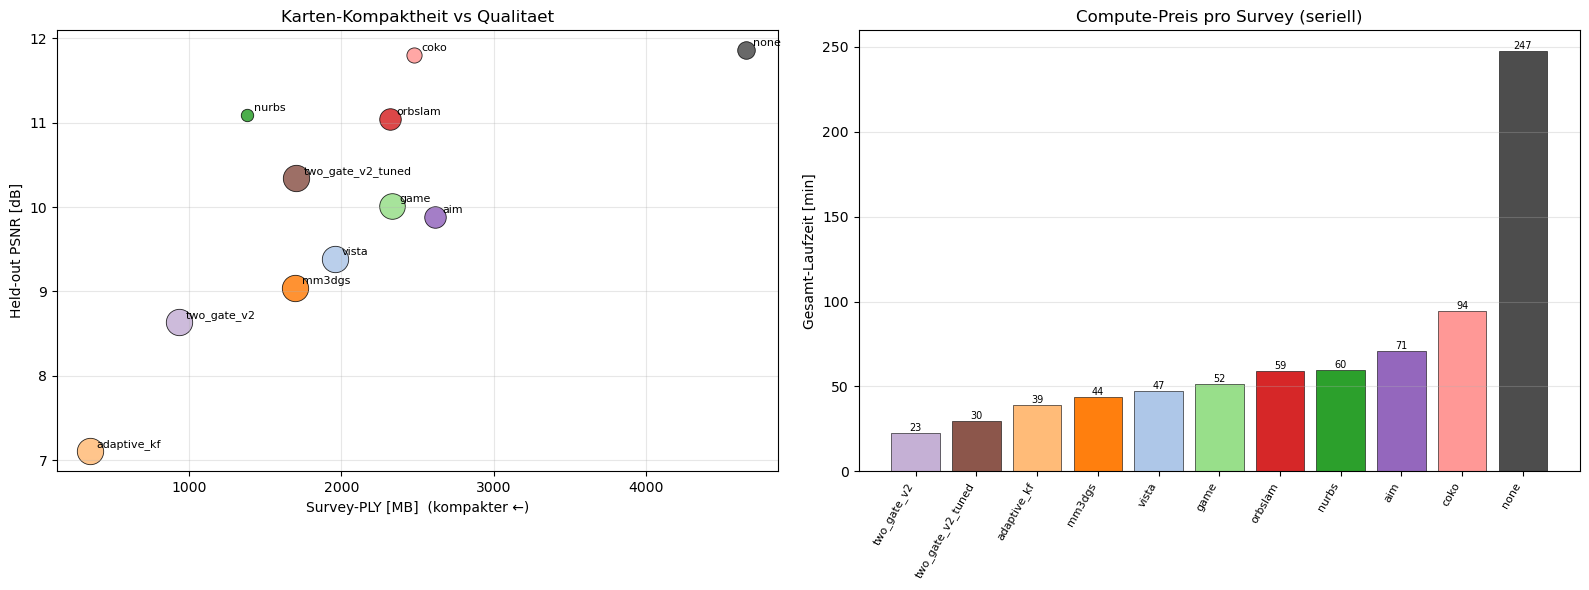

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
for _, r in df.iterrows():
    ax.scatter(r['ply_mb_merged'], r['psnr_ho_mean'], s=40 + r['n_ok'] * 20,
               color=_pal[r['survey_name']], edgecolor='black', lw=.6, alpha=.85)
    ax.annotate(r['survey_name'], (r['ply_mb_merged'], r['psnr_ho_mean']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)
ax.set_xlabel('Survey-PLY [MB]  (kompakter ←)'); ax.set_ylabel('Held-out PSNR [dB]')
ax.set_title('Karten-Kompaktheit vs Qualitaet'); ax.grid(alpha=.3)

o = df.sort_values('duration_total_min').reset_index(drop=True)
xx = np.arange(len(o))
axes[1].bar(xx, o['duration_total_min'], color=C(o['survey_name']), edgecolor='black', lw=.4)
axes[1].set_xticks(xx); axes[1].set_xticklabels(o['survey_name'], rotation=60, ha='right', fontsize=8)
axes[1].set_ylabel('Gesamt-Laufzeit [min]'); axes[1].set_title('Compute-Preis pro Survey (seriell)')
axes[1].grid(alpha=.3, axis='y')
for xi, v in zip(xx, o['duration_total_min']):
    axes[1].text(xi, v, f'{v:.0f}', ha='center', va='bottom', fontsize=7)
fig.tight_layout(); plt.show()

## 9) PSNR-Streuung ueber die Segmente

`psnr_ho_min/mean/max` je Selektor: wie stabil ist die Mapping-Qualitaet ueber den Flug.
Lange Whisker = stark schwankende Segmente (typisch fuer die „Schmier"-Regionen
s1900/s2200/s2800/s3400, siehe `project_survey_next_steps`).

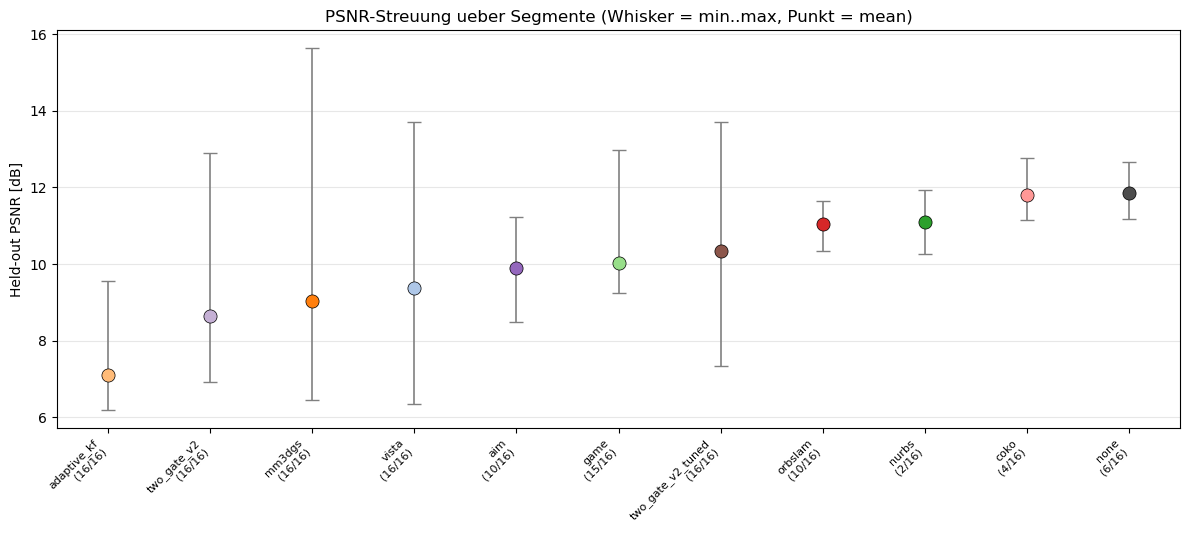

In [15]:
o = df.sort_values('psnr_ho_mean').reset_index(drop=True)
x = np.arange(len(o))
lo = (o['psnr_ho_mean'] - o['psnr_ho_min']).clip(lower=0)
hi = (o['psnr_ho_max'] - o['psnr_ho_mean']).clip(lower=0)
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.errorbar(x, o['psnr_ho_mean'], yerr=[lo, hi], fmt='o', ms=8, capsize=5,
            ecolor='grey', mfc='none', mec='black', lw=1.2, zorder=2)
for xi, s in zip(x, o['survey_name']):
    ax.scatter(xi, o.loc[xi, 'psnr_ho_mean'], s=90, color=_pal[s], zorder=3, edgecolor='black', lw=.5)
ax.set_xticks(x); ax.set_xticklabels([f'{s}\n({int(n)}/16)' for s, n in zip(o['survey_name'], o['n_ok'])],
                                     rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Held-out PSNR [dB]')
ax.set_title('PSNR-Streuung ueber Segmente (Whisker = min..max, Punkt = mean)')
ax.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()

## Fazit (Datenstand 2026-06-10, inkl. `two_gate_v2_tuned`)

* **Drosseln zahlt sich in Vollstaendigkeit aus.** `none`/`coko`/`nurbs` mappen am
  meisten und sterben am VRAM-Wall (6/4/2 von 16 Segmenten). Die harten Throttler
  `vista`/`mm3dgs`/`adaptive_kf`/`two_gate_v2` bringen **16/16** durch.
* **`two_gate_v2` war ueber-gedrosselt.** Die metrisch (s1000) getunten Schwellen
  hungerten den Mapper auf dem non-metrischen Survey aus (201 KFs, psnr_ho 8.64 =
  Survey-Letzter). **`two_gate_v2_tuned`** (`pose_d_min_m 0.2→0.1`, Cap `2→6`,
  `theta0 0.15→0.08`, `gps_d_min_m 0.4→0.2`) mappt 479 KFs und hebt psnr_ho auf
  **10.34 dB (+1.7)** bei gleicher ATE (12.15, 2.-beste im Feld) und weiterhin 16/16
  Segmenten — von Platz 11 ins obere Mittelfeld, schlaegt vista/mm3dgs/game/aim/adaptive_kf.
  Bleibt mit ~30 min + Peak-VRAM ~2 GiB der Effizienz-Sweetspot.
* **Generalisierbar:** Selektoren mit scale-abhaengigen Schwellen (pose-translation, theta)
  muessen auf dem non-metrischen Survey nachskaliert werden; der harte Rate-Cap ist die
  erste verdaechtige Drossel. Diagnose via Gate-Tally
  `grep -oP 'fs\(step=\K[^)]+' run_*.log | sort | uniq -c`.
* **Qualitaetszahlen NICHT roh ranken.** Die hohen `psnr_ho`/niedrigen `ate` von
  `none`/`nurbs`/`coko` stammen aus wenigen ueberlebenden (einfacheren) Segmenten
  (Coverage-Confound). Fair vergleichbar sind primaer die 16/16-Selektoren.
* **Posen sind non-metrisch** (`--no-ext`): `ate` = Tracker-Drift, nicht Kartenfehler.

Quelle: `docs/results/survey_selectors_summary.csv` · Harness:
`scripts/run_survey_all_selectors.sh` · Mess-Code: `scripts/eval/measure_survey.py`.